# Bernstein-Vazirani Algorithm using Qiskit

## Overview

The Bernstein-Vazirani Algorithm is one of the earliest quantum algorithms that demonstrates a clear advantage over classical computation.

Problem:

A hidden binary string s exists.

Example:

s = 1011

An oracle computes:

f(x) = s·x mod 2

where · denotes bitwise inner product modulo 2.

Goal:

Recover the entire hidden string.

---

## Classical Approach

To discover every bit of s:

Need n oracle queries.

Example:

s = 1011

Need:

f(1000)
f(0100)
f(0010)
f(0001)

Total = n queries

---

## Quantum Approach

Using superposition and phase kickback:

Recover all bits of s with ONE oracle query.

---

## Concepts Covered

- Hadamard Gate
- Superposition
- Phase Kickback
- Oracle Construction
- Interference
- Measurement

---

## Visualizations

- Circuit Diagrams
- Statevector Plots
- Bloch Sphere Visualizations
- State City Plots
- Probability Histograms
- Hidden String Verification
- Query Comparison

---

## Installation

pip install qiskit qiskit-aer matplotlib pylatexenc

Author: Muhammad Saad

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=13a657d1294ce9bf6c65a5210f3e8efcc42e1e76d16e3eeb68736d91d965a8ca
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_city
)

from qiskit_aer import AerSimulator

from IPython.display import display

In [ ]:
def visualize_state(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    print("\nProbabilities:")
    probs = state.probabilities_dict()

    for k,v in probs.items():
        print(f"{k}: {v:.4f}")

    display(plot_state_city(state))
    display(plot_bloch_multivector(state))

    return state

# Bernstein-Vazirani Algorithm

Goal:

Discover a hidden binary string.

Example:

Hidden String:

1011

Classically:

Need one query per bit.

Quantum:

Need only ONE oracle query.

The algorithm uses:

- Superposition
- Phase Kickback
- Interference

In [ ]:
# Step 1 — Secret String

secret_string = "1011"

print()
print("Alice secretly chooses:")
print(secret_string)

print()
print("Bob's mission:")
print("Discover the secret string.")


Alice secretly chooses:
1011

Bob's mission:
Discover the secret string.


In [ ]:
# Classical Demonstration

secret_string = "1011"

print("="*60)
print("CLASSICAL APPROACH")
print("="*60)

for i in range(len(secret_string)):

    query = ["0"]*len(secret_string)

    query[i] = "1"

    query = "".join(query)

    print(f"Query: {query}")
    print(f"Response reveals bit {i}")
    print()

print(f"Total Queries Required = {len(secret_string)}")

CLASSICAL APPROACH
Query: 1000
Response reveals bit 0

Query: 0100
Response reveals bit 1

Query: 0010
Response reveals bit 2

Query: 0001
Response reveals bit 3

Total Queries Required = 4


In [ ]:
# Quantum Oracle Builder

def bv_oracle(secret):

    n = len(secret)

    qc = QuantumCircuit(n+1)

    for i,bit in enumerate(secret):

        if bit == "1":
            qc.cx(i,n)

    return qc

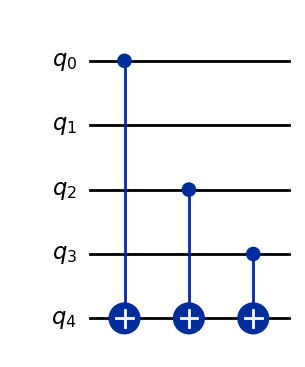

In [ ]:
# Visualize Oracle

secret_string = "1011"

oracle = bv_oracle(secret_string)

display(oracle.draw("mpl"))

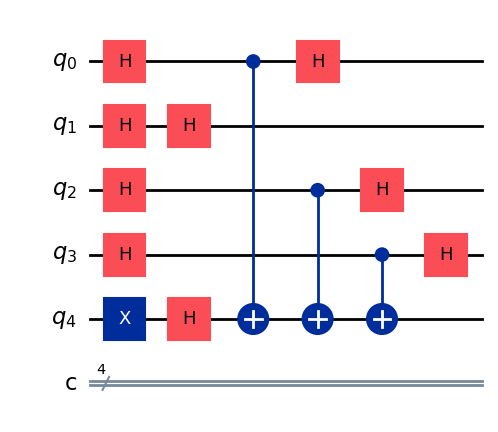

In [ ]:
n = len(secret_string)

qc = QuantumCircuit(n+1,n)

qc.x(n)

for q in range(n+1):
    qc.h(q)

oracle = bv_oracle(secret_string)

qc.compose(oracle,inplace=True)

for q in range(n):
    qc.h(q)

display(qc.draw("mpl"))

State Before Measurement


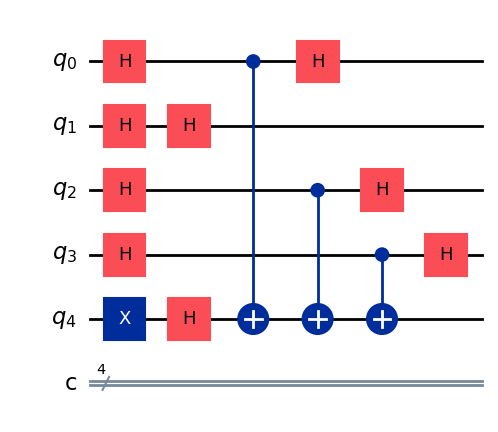


Statevector:
Statevector([ 1.25211142e-51+0.j,  1.78038433e-34+0.j, -8.03696306e-68+0.j,
             -9.89746461e-51+0.j,  1.98240910e-34+0.j,  1.34692639e-17+0.j,
              9.30361298e-52+0.j,  1.70104734e-34+0.j, -2.58608688e-34+0.j,
             -6.29457921e-18+0.j, -2.88786304e-50+0.j, -2.44064821e-34+0.j,
              1.66988925e-17+0.j,  7.07106781e-01+0.j,  6.49514367e-34+0.j,
             -9.52420783e-18+0.j, -1.25211142e-51+0.j, -1.78038433e-34+0.j,
              8.03696306e-68+0.j,  9.89746461e-51+0.j, -1.98240910e-34+0.j,
             -1.34692639e-17+0.j, -9.30361298e-52+0.j, -1.70104734e-34+0.j,
              2.58608688e-34+0.j,  6.29457921e-18+0.j,  2.88786304e-50+0.j,
              2.44064821e-34+0.j, -1.66988925e-17+0.j, -7.07106781e-01+0.j,
             -6.49514367e-34+0.j,  9.52420783e-18+0.j],
            dims=(2, 2, 2, 2, 2))

Probabilities:
00000: 0.0000
00001: 0.0000
00010: 0.0000
00011: 0.0000
00100: 0.0000
00101: 0.0000
00110: 0.0000
00111: 0.0000
01000: 0

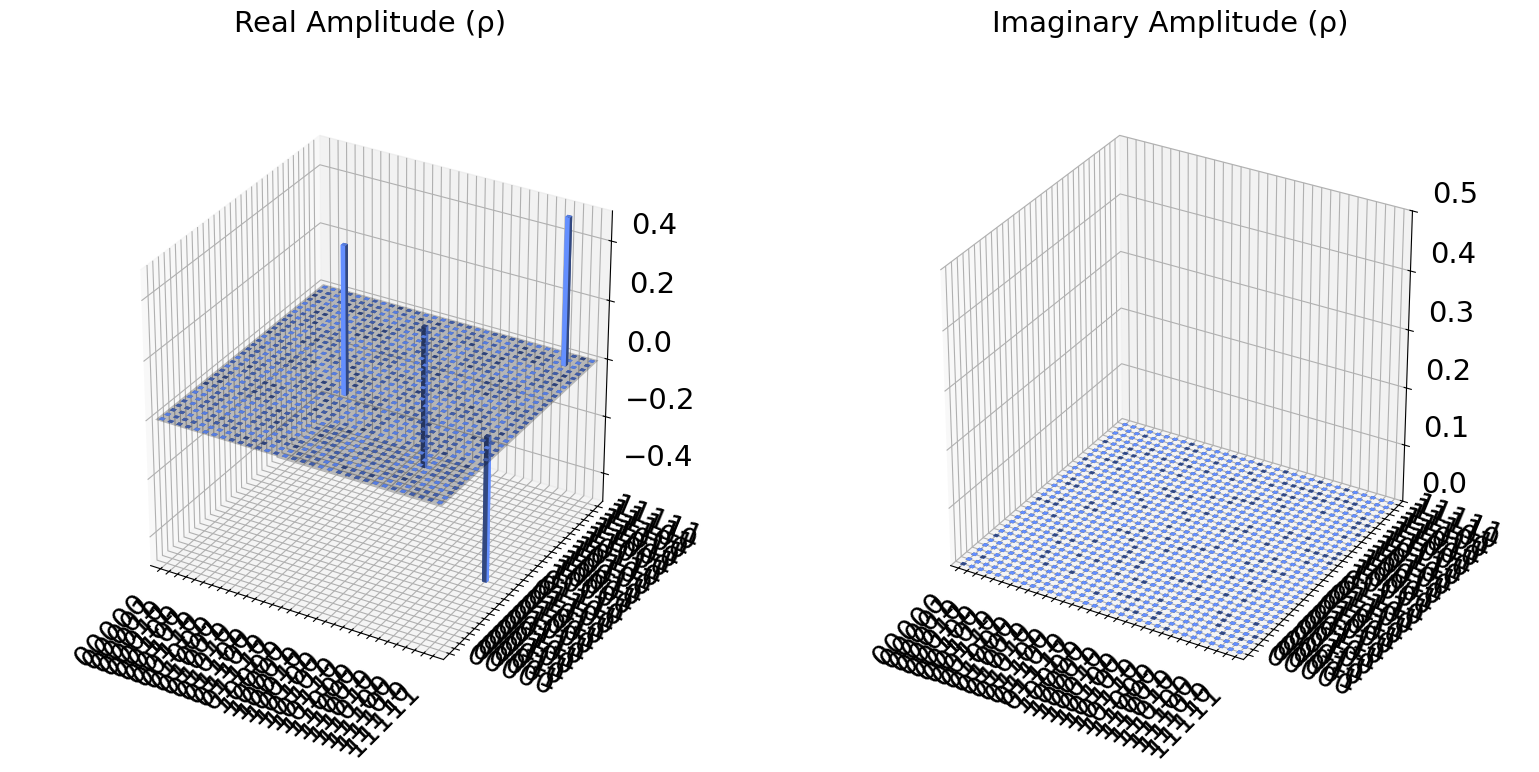

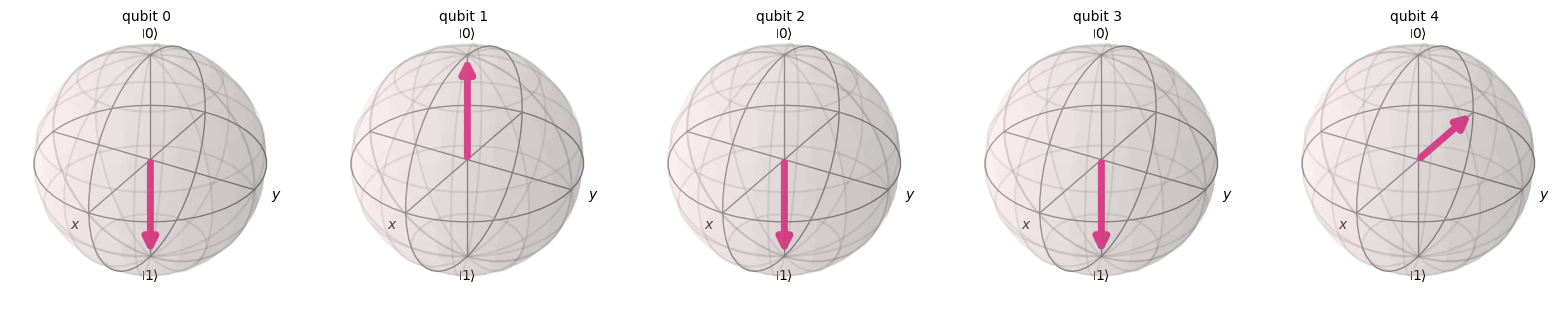

Statevector([ 1.25211142e-51+0.j,  1.78038433e-34+0.j, -8.03696306e-68+0.j,
             -9.89746461e-51+0.j,  1.98240910e-34+0.j,  1.34692639e-17+0.j,
              9.30361298e-52+0.j,  1.70104734e-34+0.j, -2.58608688e-34+0.j,
             -6.29457921e-18+0.j, -2.88786304e-50+0.j, -2.44064821e-34+0.j,
              1.66988925e-17+0.j,  7.07106781e-01+0.j,  6.49514367e-34+0.j,
             -9.52420783e-18+0.j, -1.25211142e-51+0.j, -1.78038433e-34+0.j,
              8.03696306e-68+0.j,  9.89746461e-51+0.j, -1.98240910e-34+0.j,
             -1.34692639e-17+0.j, -9.30361298e-52+0.j, -1.70104734e-34+0.j,
              2.58608688e-34+0.j,  6.29457921e-18+0.j,  2.88786304e-50+0.j,
              2.44064821e-34+0.j, -1.66988925e-17+0.j, -7.07106781e-01+0.j,
             -6.49514367e-34+0.j,  9.52420783e-18+0.j],
            dims=(2, 2, 2, 2, 2))


In [ ]:
# Before Running

state_qc = qc.copy()

visualize_state(
    state_qc,
    "State Before Measurement"
)

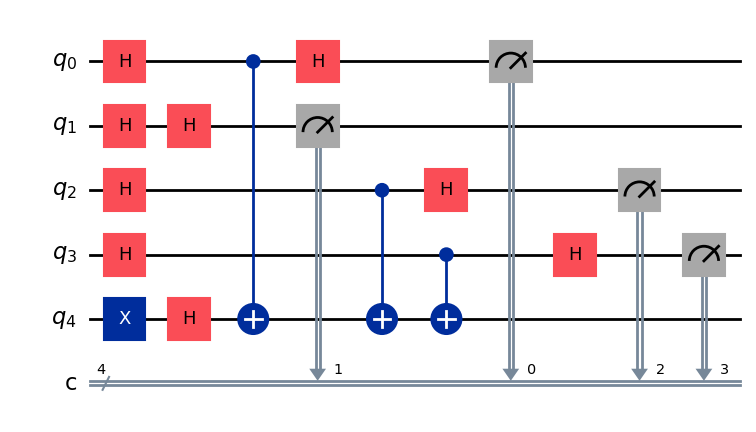

In [ ]:
# Measurement

for q in range(n):
    qc.measure(q,q)

display(qc.draw("mpl"))

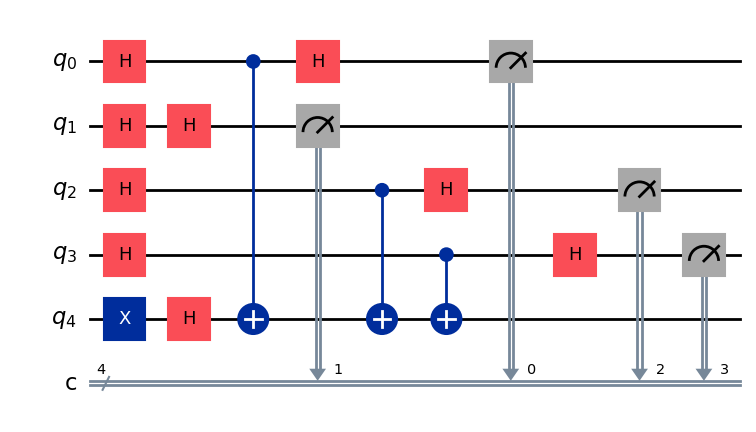

Counts:
{'1101': 1000}


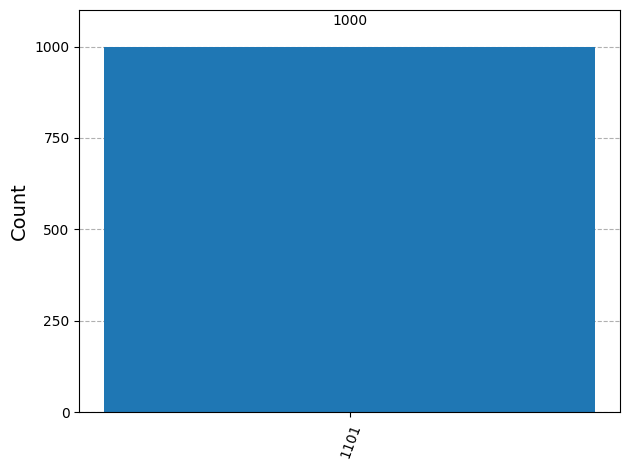

In [ ]:
# Run Algorithm

# Add measurements
qc.measure(range(n), range(n))

display(qc.draw("mpl"))

sim = AerSimulator()

result = sim.run(
    qc,
    shots=1000
).result()

counts = result.get_counts()

print("Counts:")
print(counts)

display(plot_histogram(counts))

In [ ]:
measured = max(counts,key=counts.get)

print()
print("="*60)
print("BERNSTEIN-VAZIRANI RESULT")
print("="*60)

print()
print("Alice's Secret String:")
print(secret_string)

print()
print("Quantum Computer Found:")
print(measured)

print()

if measured == secret_string:
    print("SUCCESS ✓")
else:
    print("Check Qiskit bit ordering.")

n = len(secret_string)

print()
print("="*60)
print("QUERY COMPARISON")
print("="*60)

print()

print(f"Classical Queries Needed : {n}")

print("Quantum Queries Needed   : 1")

print()

print(f"Improvement Factor = {n}x")


BERNSTEIN-VAZIRANI RESULT

Alice's Secret String:
1011

Quantum Computer Found:
1101

Check Qiskit bit ordering.

QUERY COMPARISON

Classical Queries Needed : 4
Quantum Queries Needed   : 1

Improvement Factor = 4x


In [ ]:
# Phase Kickback Visualization

secret_string = "1011"

print("="*60)
print("PHASE KICKBACK EXPLANATION")
print("="*60)

for i,b in enumerate(secret_string):

    if b == "1":
        print(f"Bit {i}: Phase Flipped")
    else:
        print(f"Bit {i}: No Phase Flip")

PHASE KICKBACK EXPLANATION
Bit 0: Phase Flipped
Bit 1: No Phase Flip
Bit 2: Phase Flipped
Bit 3: Phase Flipped
